# 2.5 Bundle-priced EIP-7999 dynamic replay and demand shocks

This notebook replaces the demand layer in notebook 2.1 with the bundle-priced
BAL model from publication notebook `7999_equilibrium/03`. The EIP-7999 fee transition remains exact and
block-by-block. The new demand evaluator keeps static data separate from BAL:

- an execution demand shift changes execution and execution-generated BAL;
- a state demand shift changes state creation and state-generated BAL;
- a static-data demand shift changes calldata, access lists, authorization
  tuples, and blob-versioned hashes, without directly multiplying BAL.

The empirical residuals below are **elasticity-conditional demand conditions**.
They are the multiplicative shifts required to reconcile historical usage with
the maintained demand curves after removing the modeled price response and a
slow trend. They do not causally identify NFT mints, token launches, or other
named events. Directional event stresses are added separately and transparently.

Status of this scaffold:

- fee mechanics and bundle-priced demand equations: implemented exactly;
- slow demand conditions: estimated from the 120-day daily panel;
- within-day dispersion: approximated from 6,000 sampled Xatu blocks;
- block-to-block persistence: not yet identified, because those 6,000 blocks
  are deliberately spaced rather than contiguous.

> **Status:** this is the exploratory predecessor of the publication replay.
> The dynamic report is generated by `src/dynamics/batched_replay.py` and the
> `scripts/run_*` pipeline, which keeps the same bundle-priced demand and
> parent–BAL-consistent inclusion logic but estimates short-run shocks from a
> contiguous 100,439-block panel. Numerical results from this notebook and the
> report are therefore not direct replications of one another.


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import pandas as pd
from IPython.display import display

WORKING_DIR = Path.cwd().resolve()
PROJECT_ROOT = next(
    (path for path in (WORKING_DIR, *WORKING_DIR.parents) if (path / "src").is_dir()),
    None,
)
if PROJECT_ROOT is None:
    raise RuntimeError("Could not locate the project root containing src/")
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from demand import (
    JointShockPanel,
    JointShockPath,
    ShockEstimationSpec,
    estimate_joint_shocks,
    vector_moving_block_bootstrap,
)
from dynamics import (
    BundlePriced7999Demand,
    ParentBALConsistentCaps,
    run_driven_full_7999,
    summarize_driven_replay,
)
from mechanisms import make_full_7999_config

DATA_DIR = PROJECT_ROOT / "data"
PLOTS_DIR = PROJECT_ROOT / "plots"
PLOTS_DIR.mkdir(exist_ok=True)

DATE_LABEL = "2026-02-01_2026-06-01"
RESOURCES = ("execution", "data", "state")
COLORS = {
    "execution": "#4c78a8",
    "data": "#f58518",
    "state": "#54a24b",
}
LABELS = {
    "execution": "execution",
    "data": "static data",
    "state": "state creation",
}
RESOURCE_LABELS = {
    "execution": "execution",
    "data": "data",
    "state": "state",
}

plt.rcParams.update(
    {
        "font.size": 14,
        "axes.titlesize": 16,
        "axes.labelsize": 14,
        "xtick.labelsize": 13,
        "ytick.labelsize": 13,
        "legend.fontsize": 12,
        "figure.titlesize": 18,
    }
)
pd.set_option("display.max_columns", 80)
pd.set_option("display.float_format", lambda value: f"{value:,.6g}")


## Dynamic bundle-priced demand

Let $s_{E,t}$, $s_{D,t}$, and $s_{S,t}$ be positive, mean-one demand
conditions. With $R_{E,t}=q_{E,t}/q_E^0$, the parent activities are

$$
R_{E,t}=s_{E,t}
\left[
\frac{m_Eb_{E,t}+w_ER_{E,t}^{\rho_A-1}b_{D,t}}{p^0}
\right]^{-\epsilon_E},
$$

$$
q_{S,t}=q_S^0s_{S,t}
\left[
\frac{m_Sb_{S,t}+w_Sb_{D,t}}{p^0}
\right]^{-\epsilon_S},
$$

while static transaction data follows

$$
g_{\mathrm{static},t}=g_{\mathrm{static}}^0s_{D,t}
\left(\frac{m_Db_{D,t}}{p^0}\right)^{-\epsilon_D}.
$$

Runtime BAL is generated by the realized parent activity and a mean-preserving
access-composition factor $a_t$:

$$
g_{\mathrm{BAL},t}
=a_t\left(w_Eq_E^0R_{E,t}^{\rho_A}+w_Sq_{S,t}\right).
$$

The EIP-7999 fee mechanism therefore receives

$$
G_{E,t}=m_Eq_{E,t},\qquad
G_{S,t}=m_Sq_{S,t},\qquad
G_{D,t}=g_{\mathrm{static},t}+g_{\mathrm{BAL},t}.
$$

There is no independent BAL demand curve in the central model. A data fee affects
BAL through the all-in prices paid by execution and state activity. The factor
$a_t$ records block-level variation in access intensity for a given amount of parent
activity. It changes realized BAL after demand is chosen and is normalized so that
it does not move the historical BAL anchor.


In [2]:
card = pd.read_csv(
    DATA_DIR / f"full_7999_equilibrium_accounting_card_{DATE_LABEL}.csv"
).iloc[0]
elasticity_table = pd.read_csv(
    DATA_DIR / "three_way_isoelastic_calibration_2025.csv"
)
frontier = pd.read_csv(DATA_DIR / "bundle_pricing_execution_frontier.csv")

WINDOW_DAYS = 35
LAMBDA_BAL = 0.0
RHO_A = float(card["bal_access_rho_central"])

elasticity_row = elasticity_table.loc[
    elasticity_table["window_days"].eq(WINDOW_DAYS)
].iloc[0]
elasticities = {
    "execution": float(elasticity_row["eps_execution"]),
    "data": float(elasticity_row["eps_data"]),
    "state": float(elasticity_row["eps_state"]),
}

direct = float(card["bal_direct_state_weight"])
coproduced = float(card["bal_coproduced_state_transaction_weight"])
nonstate = float(card["bal_nonstate_transaction_weight"])
omega_state = direct + LAMBDA_BAL * coproduced
omega_execution = nonstate + (1.0 - LAMBDA_BAL) * coproduced

bal_anchor = float(card["bal_7999_gas_per_block"])
q_execution_anchor = float(card["execution_historical_quantity_per_block"])
q_state_anchor = float(card["state_historical_quantity_per_block"])
w_execution = omega_execution * bal_anchor / q_execution_anchor
w_state = omega_state * bal_anchor / q_state_anchor

metering_multipliers = {
    "execution": float(card["execution_metering_multiplier"]),
    "data": float(card["data_metering_multiplier_no_bal"]),
    "state": float(card["state_metering_multiplier"]),
}

demand_model = BundlePriced7999Demand(
    execution_quantity_anchor=q_execution_anchor,
    state_quantity_anchor=q_state_anchor,
    static_data_gas_anchor=float(card["data_7999_gas_no_bal_per_block"]),
    historical_price_wei=float(card["historical_base_fee_ref_gwei"]) * 1e9,
    metering_multipliers=metering_multipliers,
    elasticities=elasticities,
    bal_intensities={"execution": w_execution, "state": w_state},
    rho_A=RHO_A,
)

model_inputs = pd.DataFrame(
    {
        "resource": RESOURCES,
        "historical activity anchor": [
            q_execution_anchor,
            float(card["data_historical_quantity_per_block"]),
            q_state_anchor,
        ],
        "metering multiplier": [
            metering_multipliers[resource] for resource in RESOURCES
        ],
        "elasticity": [elasticities[resource] for resource in RESOURCES],
    }
)
display(model_inputs)
display(
    pd.DataFrame(
        {
            "BAL allocation": ["execution/access", "direct state creation"],
            "share": [omega_execution, omega_state],
            "data gas per unit of parent activity": [w_execution, w_state],
        }
    )
)


,resource,historical activity anchor,metering multiplier,elasticity
0,execution,2.39422e+07,1.5379,0.12116
1,data,1.18056e+06,1.80725,0.229476
2,state,5.24415e+06,5.65632,0.334864


,BAL allocation,share,data gas per unit of parent activity
0,execution/access,0.886063,0.0710227
1,direct state creation,0.113937,0.0416953


## Reserve-free equilibrium warm start

The dynamic replay fixes the data target at 30M and starts from publication notebook `7999_equilibrium/03`'s
execution-clearing frontier. This is the largest execution target that can clear
while the execution fee remains at its one-wei minimum. Data and state are interior;
all three resources therefore clear their targets up to integer-fee rounding.


In [3]:
frontier_matches = frontier.loc[
    frontier["window_days"].eq(WINDOW_DAYS)
    & np.isclose(frontier["lambda_bal"], LAMBDA_BAL)
    & np.isclose(frontier["rho_A"], RHO_A)
    & np.isclose(frontier["data_target"], 30_000_000)
    & np.isclose(frontier["state_target"], 75_000_000)
]
assert len(frontier_matches) == 1
equilibrium = frontier_matches.iloc[0]
initial_fees = {
    "execution": int(round(equilibrium["minimum_fee_wei"])),
    "data": int(round(equilibrium["data_fee_wei_at_boundary"])),
    "state": int(round(equilibrium["state_fee_wei_at_boundary"])),
}
targets = {
    "execution": int(round(equilibrium["execution_target_at_one_wei"])),
    "data": int(round(equilibrium["data_target"])),
    "state": int(round(equilibrium["state_target"])),
}

unit_evaluation = demand_model.evaluate_with_shocks(
    initial_fees,
    {resource: 1.0 for resource in RESOURCES},
)
warm_start_check = pd.DataFrame(
    {
        "resource": RESOURCES,
        "base fee (wei)": [initial_fees[r] for r in RESOURCES],
        "target gas": [targets[r] for r in RESOURCES],
        "offered gas": [unit_evaluation.offered_gas[r] for r in RESOURCES],
    }
)
warm_start_check["target difference"] = (
    warm_start_check["offered gas"] - warm_start_check["target gas"]
)
display(warm_start_check)

assert equilibrium["pinned_at_minimum"] == "execution"
assert initial_fees["execution"] == 1
assert targets["data"] == 90_000_000 // 3
for resource in RESOURCES:
    assert abs(
        unit_evaluation.offered_gas[resource] / targets[resource] - 1.0
    ) < 5e-5


,resource,base fee (wei),target gas,offered gas,target difference
0,execution,1,182249933,1.82252e+08,"2,040.33"
1,data,2764,30000000,3.00005e+07,543.686
2,state,1184451,75000000,7.5e+07,-4.50456


## Recovering historical demand conditions

For resource $i$, historical usage is adjusted for the response attributed to
the estimated elasticity:

$$
x_{i,t}=\log q_{i,t}
+\widehat\epsilon_i\log\left(\frac{p_t}{p^0}\right).
$$

A centered rolling median $\widehat\mu_{i,t}$ removes slow movement, and the
remaining positive factor is normalized to mean one:

$$
s_{i,t}=\frac{\exp(x_{i,t}-\widehat\mu_{i,t})}
{\operatorname{mean}_t\exp(x_{i,t}-\widehat\mu_{i,t})}.
$$

The decomposition is conditional on the elasticity and trend window. A high
residual means usage was high relative to the maintained price-response model;
it does not by itself reveal the event that caused the demand.

The data elasticity was estimated on historical charged calldata gas: the
4/16 schedule plus the EIP-7623 floor branch. The data demand condition must
therefore be recovered from that same quantity. Because the resulting shock
is dimensionless, it can then shift the full EIP-7999 static-data anchor,
which adds access lists, authorization tuples, and blob-versioned hashes.
BAL remains outside this shock because the dynamic model derives it from
execution and state activity.


In [4]:
daily = pd.read_csv(
    DATA_DIR
    / f"daily_accounting_panel_calibrated_with_bal_{DATE_LABEL}.csv"
)
historical_data = pd.read_csv(
    DATA_DIR / f"daily_current_data_gas_xatu_{DATE_LABEL}.csv",
    usecols=["date", "data_gas_current"],
)
daily = daily.merge(
    historical_data,
    on="date",
    how="inner",
    validate="one_to_one",
)
daily["date"] = pd.to_datetime(daily["date"])

# Match publication notebook resource_demand_and_glamsterdam_equilibrium/03's historical quantity convention exactly.
daily["execution_usage"] = (
    daily["current_gas_used"]
    - daily["data_gas_current"]
    - daily["current_state_creation_gas_calibrated"]
) / daily["block_count"]
daily["data_usage"] = daily["data_gas_current"] / daily["block_count"]
daily["state_usage"] = (
    daily["current_state_creation_gas_calibrated"] / daily["block_count"]
)

aggregate_anchors = {
    "execution": (
        daily["current_gas_used"]
        - daily["data_gas_current"]
        - daily["current_state_creation_gas_calibrated"]
    ).sum() / daily["block_count"].sum(),
    "data": daily["data_gas_current"].sum() / daily["block_count"].sum(),
    "state": (
        daily["current_state_creation_gas_calibrated"].sum()
        / daily["block_count"].sum()
    ),
}
card_anchors = {
    "execution": float(card["execution_historical_quantity_per_block"]),
    "data": float(card["data_historical_quantity_per_block"]),
    "state": float(card["state_historical_quantity_per_block"]),
}
for resource in RESOURCES:
    assert abs(aggregate_anchors[resource] / card_anchors[resource] - 1) < 1e-9

def estimate_daily_panel(window_days, trend_window=21):
    row = elasticity_table.loc[
        elasticity_table["window_days"].eq(window_days)
    ].iloc[0]
    epsilon = {
        "execution": float(row["eps_execution"]),
        "data": float(row["eps_data"]),
        "state": float(row["eps_state"]),
    }
    spec = ShockEstimationSpec(
        time_col="date",
        usage_cols={
            "execution": "execution_usage",
            "data": "data_usage",
            "state": "state_usage",
        },
        price_cols="median_base_fee_per_gas",
        elasticities=epsilon,
        frequency="day",
        basis="historical_physical",
        trend_window=trend_window,
    )
    return estimate_joint_shocks(
        daily,
        spec,
        source=(
            f"120-day historical quantities; {window_days}-day elasticity; "
            f"{trend_window}-day rolling-median trend"
        ),
    )

daily_shocks = estimate_daily_panel(WINDOW_DAYS, trend_window=21)
daily_shocks.values.to_csv(
    DATA_DIR / f"bundle_dynamic_daily_shocks_{DATE_LABEL}.csv"
)

def shock_diagnostics(panel):
    log_values = np.log(panel.values)
    return pd.DataFrame(
        {
            "resource": RESOURCES,
            "p05": [panel.values[r].quantile(0.05) for r in RESOURCES],
            "median": [panel.values[r].median() for r in RESOURCES],
            "p95": [panel.values[r].quantile(0.95) for r in RESOURCES],
            "log standard deviation": [log_values[r].std() for r in RESOURCES],
            "lag-one daily correlation": [
                log_values[r].autocorr(lag=1) for r in RESOURCES
            ],
        }
    )

display(pd.DataFrame({"resource": RESOURCES, "recovered anchor": aggregate_anchors.values(), "accounting-card anchor": card_anchors.values()}))
display(shock_diagnostics(daily_shocks))
display(daily_shocks.values.corr().rename_axis("resource"))

,resource,recovered anchor,accounting-card anchor
0,execution,2.39422e+07,2.39422e+07
1,data,1.18056e+06,1.18056e+06
2,state,5.24415e+06,5.24415e+06


,resource,p05,median,p95,log standard deviation,lag-one daily correlation
0,execution,0.867806,0.995409,1.12217,0.0843263,0.465784
1,data,0.751646,0.979189,1.39016,0.187407,0.529496
2,state,0.759539,0.976488,1.31887,0.165439,0.394477


,execution,data,state
resource,,,
execution,1,0.543889,0.164168
data,0.543889,1,0.242349
state,0.164168,0.242349,1


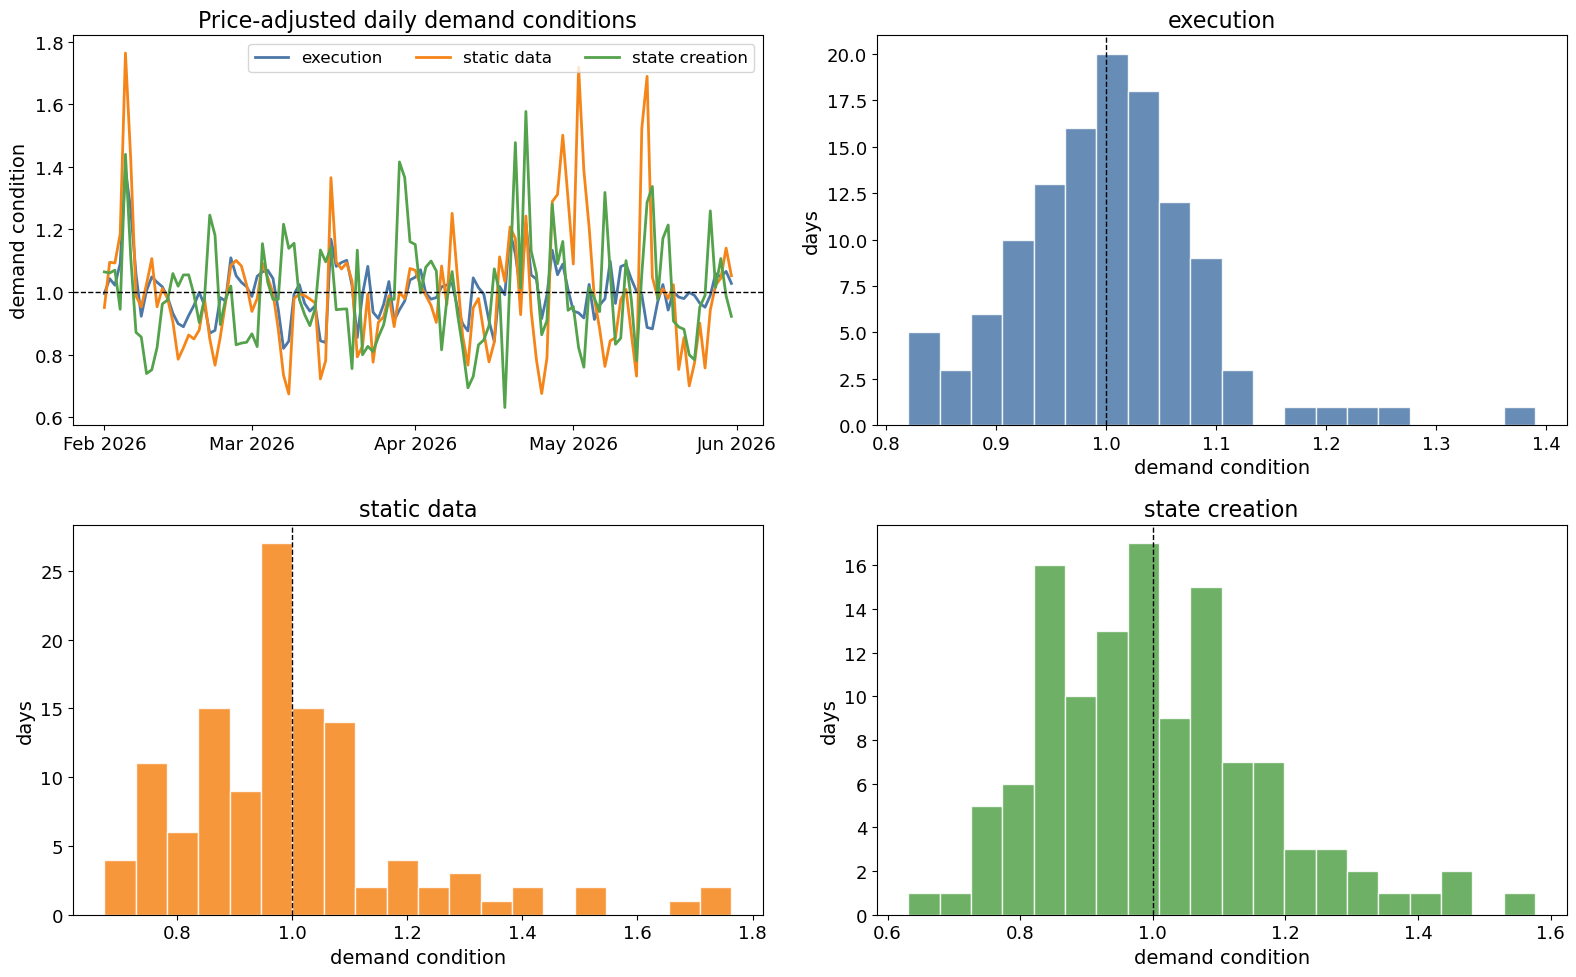

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
for resource in RESOURCES:
    axes[0, 0].plot(
        daily_shocks.values.index,
        daily_shocks.values[resource],
        color=COLORS[resource],
        linewidth=2,
        label=LABELS[resource],
    )
axes[0, 0].axhline(1, color="black", linewidth=1, linestyle="--")
axes[0, 0].set_ylabel("demand condition")
axes[0, 0].set_title("Price-adjusted daily demand conditions")
axes[0, 0].legend(ncol=3)
axes[0, 0].xaxis.set_major_locator(mdates.MonthLocator())
axes[0, 0].xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))

for resource, axis in zip(RESOURCES, [axes[0, 1], axes[1, 0], axes[1, 1]]):
    axis.hist(
        daily_shocks.values[resource],
        bins=20,
        color=COLORS[resource],
        alpha=0.85,
        edgecolor="white",
    )
    axis.axvline(1, color="black", linewidth=1, linestyle="--")
    axis.set_title(LABELS[resource])
    axis.set_xlabel("demand condition")
    axis.set_ylabel("days")

fig.tight_layout()
fig.savefig(
    PLOTS_DIR / f"bundle_dynamic_daily_shocks_{DATE_LABEL}.png",
    dpi=180,
    bbox_inches="tight",
)
plt.show()


### Identification sensitivity

Demand conditions are re-estimated whenever the elasticity window changes.
The table also varies the detrending window. This exposes how much of the
historical variation is assigned to price response, slow movement, or the
remaining demand condition.


In [6]:
sensitivity_rows = []
for elasticity_window in (21, 35, 60, 75):
    for trend_window in (7, 21, 35):
        panel = estimate_daily_panel(elasticity_window, trend_window)
        log_values = np.log(panel.values)
        sensitivity_rows.append(
            {
                "elasticity window": elasticity_window,
                "trend window": trend_window,
                **{
                    f"{resource} log std": log_values[resource].std()
                    for resource in RESOURCES
                },
            }
        )
shock_sensitivity = pd.DataFrame(sensitivity_rows)
display(shock_sensitivity)


,elasticity window,trend window,execution log std,data log std,state log std
0,21,7,0.0669664,0.125514,0.166511
1,21,21,0.0824489,0.178922,0.21109
2,21,35,0.102298,0.195213,0.232053
3,35,7,0.0683507,0.132481,0.134717
4,35,21,0.0843263,0.187407,0.165439
5,35,35,0.104531,0.20505,0.176756
6,60,7,0.054794,0.126149,0.124806
7,60,21,0.0662904,0.179475,0.154238
8,60,35,0.0826607,0.196242,0.165462
9,75,7,0.0537235,0.125427,0.12109


## Preliminary within-day factors from the 6,000-block panel

The cached panel has 50 deliberately spaced blocks per day. It is useful for
same-block cross-resource dispersion, but it cannot identify 12-second
autocorrelation or burst duration. We therefore normalize each metered-gas
measure by its own daily mean and sample these vectors jointly and independently
within each simulated day:

- counterfactual EIP-7999 execution gas for within-day execution activity;
- exact EIP-8131 static-data gas for within-day static data;
- counterfactual EIP-8037 state gas for within-day state creation.

The metered factors preserve observed same-block co-movement, but variation in
the EIP-8037 metering ratio is also treated as state-usage variation. These
factors are therefore an interim mechanics device. The cache has no block-level
base-fee field, so they cannot be de-elasticized and may retain some historical
price response. Feeding them into elastic demand can therefore double-count
that response. The resulting fee volatility and limit-hit rates are diagnostics
of the mechanism under this proxy dispersion, rather than empirical estimates.
A contiguous price-and-usage panel must replace them before those outcomes are
reported as historical simulations.


In [7]:
# Metered gas, not transaction and write counts. Counts reproduce the marginal
# dispersion but understate cross-resource co-movement, and co-movement is what
# decides whether two limits bind in the same block.
block_metered = pd.read_parquet(
    DATA_DIR
    / f"calibration_xatu_bal_runtime_8279_carrier_blocks_{DATE_LABEL}.parquet",
    columns=[
        "date",
        "block_number",
        "execution_metered_gas_7999",
        "state_metered_gas_8037",
        "bal_runtime_bytes_8279",
    ],
)
block_static = pd.read_csv(
    DATA_DIR / f"calibration_rpc_static_data_blocks_{DATE_LABEL}.csv",
    usecols=["block_number", "static_data_gas_7999"],
)
block_panel = block_metered.merge(
    block_static,
    on="block_number",
    how="inner",
    validate="one_to_one",
)
block_panel["date"] = pd.to_datetime(block_panel["date"])

raw_fast = pd.DataFrame(
    {
        "date": block_panel["date"],
        "block_number": block_panel["block_number"].astype(int),
        "execution": block_panel["execution_metered_gas_7999"].clip(lower=1.0),
        "data": block_panel["static_data_gas_7999"].clip(lower=1.0),
        "state": block_panel["state_metered_gas_8037"].clip(lower=1.0),
    }
)
fast_values = pd.DataFrame(index=raw_fast.index)
for resource in RESOURCES:
    daily_mean = raw_fast.groupby("date")[resource].transform("mean")
    fast_values[resource] = raw_fast[resource] / daily_mean
    fast_values[resource] /= fast_values[resource].mean()
fast_values.index = raw_fast["block_number"].to_numpy()
fast_values.index.name = "block_number"
fast_values = fast_values.sort_index()

within_day_factors = JointShockPanel(
    values=fast_values,
    frequency="block",
    basis="7999_metered",
    source="6,000 spaced Xatu blocks; metered within-day factors; no persistence",
)
within_day_factors.values.to_csv(
    DATA_DIR / f"bundle_dynamic_within_day_factors_{DATE_LABEL}.csv"
)

spacing = np.diff(np.sort(raw_fast["block_number"].to_numpy()))
fast_diagnostics = pd.DataFrame(
    {
        "blocks": [len(raw_fast)],
        "adjacent block pairs": [int((spacing == 1).sum())],
        "adjacent pair share": [float((spacing == 1).mean())],
        "zero static-data observations clipped": [
            int((block_panel["static_data_gas_7999"] == 0).sum())
        ],
    }
)
display(fast_diagnostics)
fast_cross_section = pd.DataFrame(
    {
        "resource": RESOURCES,
        "p05": [within_day_factors.values[r].quantile(0.05) for r in RESOURCES],
        "median": [within_day_factors.values[r].median() for r in RESOURCES],
        "p95": [within_day_factors.values[r].quantile(0.95) for r in RESOURCES],
        "log standard deviation": [
            np.log(within_day_factors.values[r]).std() for r in RESOURCES
        ],
    }
)
display(fast_cross_section)
display(within_day_factors.values.corr().rename_axis("resource"))


# Access-composition residual: observed runtime BAL against what the same
# block's parent activity implies. BAL has no demand curve, so this is not a
# fourth demand shock; it is news about how access-heavy a block was, and the
# parent curves cannot express it.
DATA_GAS_PER_BAL_BYTE = 16.0
parent_implied_bal = (
    w_execution
    * block_panel["execution_metered_gas_7999"]
    / metering_multipliers["execution"]
    + w_state
    * block_panel["state_metered_gas_8037"]
    / metering_multipliers["state"]
)
raw_access = (
    DATA_GAS_PER_BAL_BYTE * block_panel["bal_runtime_bytes_8279"]
) / parent_implied_bal
# Empty blocks carry no parent activity and no BAL, so their composition is
# undefined rather than extreme. They take the neutral factor.
undefined_access = ~np.isfinite(raw_access) | (raw_access <= 0)
raw_access = raw_access.mask(undefined_access, 1.0)
# Normalize by parent-implied BAL weight within each day. This preserves the
# daily BAL anchor despite the negative covariance between parent activity
# and access intensity; an ordinary mean-one normalization does not.
parent_fast_bal = (
    w_execution
    * q_execution_anchor
    * within_day_factors.values.loc[block_panel["block_number"], "execution"].to_numpy()
    + w_state
    * q_state_anchor
    * within_day_factors.values.loc[block_panel["block_number"], "state"].to_numpy()
)
weighted_daily_access = (
    pd.Series(parent_fast_bal * raw_access.to_numpy())
    .groupby(block_panel["date"])
    .transform("sum")
    / pd.Series(parent_fast_bal).groupby(block_panel["date"]).transform("sum")
)
access_factor = raw_access.reset_index(drop=True) / weighted_daily_access
access_factor.index = block_panel["block_number"].to_numpy()
access_factor = access_factor.sort_index()
if not np.isfinite(access_factor).all() or (access_factor <= 0).any():
    raise ValueError("access-composition factors must be finite and positive")
normalized_bal_ratio = float(
    np.mean(parent_fast_bal * access_factor.loc[block_panel["block_number"]].to_numpy())
    / bal_anchor
)
assert abs(normalized_bal_ratio - 1.0) < 1e-12

access_diagnostics = pd.DataFrame(
    {
        "statistic": [
            "blocks with undefined composition",
            "BAL anchor ratio after normalization",
            "log standard deviation",
            "correlation with execution factor",
            "correlation with data factor",
            "correlation with state factor",
        ],
        "value": [
            float(undefined_access.sum()),
            normalized_bal_ratio,
            float(np.log(access_factor).std()),
            *[
                float(np.corrcoef(access_factor, within_day_factors.values[r])[0, 1])
                for r in RESOURCES
            ],
        ],
    }
)
display(access_diagnostics)


,blocks,adjacent block pairs,adjacent pair share,zero static-data observations clipped
0,6000,38,0.00633439,3


,resource,p05,median,p95,log standard deviation
0,execution,0.350478,0.947748,1.86731,0.641098
1,data,0.257208,0.907099,2.0515,0.717896
2,state,0.176029,0.757592,2.62681,0.983397


,execution,data,state
resource,,,
execution,1,0.741514,0.328059
data,0.741514,1,0.258827
state,0.328059,0.258827,1


,statistic,value
0,blocks with undefined composition,3
1,BAL anchor ratio after normalization,1
2,log standard deviation,0.192961
3,correlation with execution factor,-0.230551
4,correlation with data factor,-0.208795
5,correlation with state factor,-0.126409


## Construct a multiscale block path

The preliminary block-frequency environment is

$$
s_{i,b}=s^{\mathrm{slow}}_{i,d(b)}\nu_{i,b},
$$

where daily vectors are drawn in circular two-day blocks to form a seven-day path,
and the
within-day vectors are sampled jointly from the spaced-block panel. The same
path is used in every mechanism comparison below.

The daily factor is intentionally constant within a day; the within-day factor
prevents one daily observation from being repeated as the complete 12-second
shock. A later contiguous Xatu panel should replace the independent within-day
draws and determine the appropriate moving-block length.


In [8]:
SEED = 7999
BLOCKS_PER_DAY = 7_200
SIMULATION_DAYS = 7
N_BLOCKS = BLOCKS_PER_DAY * SIMULATION_DAYS

DAILY_BLOCK_LENGTH = 2

def build_block_path(seed):
    """One block-frequency realization: daily condition x within-day factor.

    The daily component is resampled in contiguous multi-day blocks so that a
    run is not conditional on a single historical week. The within-day factor
    and the access residual are drawn on the same row index, which preserves
    their joint structure including the negative access/execution correlation.
    """
    slow_days = vector_moving_block_bootstrap(
        daily_shocks,
        n_steps=SIMULATION_DAYS,
        block_length=DAILY_BLOCK_LENGTH,
        seed=seed,
        circular=True,
    )
    rng = np.random.default_rng(seed + 1)
    fast_positions = rng.integers(
        0,
        len(within_day_factors.values),
        size=N_BLOCKS,
    )
    slow_values = np.repeat(
        slow_days.values.to_numpy(dtype=float),
        BLOCKS_PER_DAY,
        axis=0,
    )
    fast_draws = within_day_factors.values.iloc[
        fast_positions
    ].to_numpy(dtype=float)
    path = JointShockPath(
        values=pd.DataFrame(slow_values * fast_draws, columns=RESOURCES),
        frequency="block",
        basis=within_day_factors.basis,
        source=(
            "historical daily demand conditions x 7999-metered "
            "spaced-block joint factors"
        ),
        source_positions=tuple(int(position) for position in fast_positions),
    )
    access_draws = access_factor.to_numpy(dtype=float)[fast_positions]
    return path, access_draws, slow_days

empirical_path, empirical_access, slow_days = build_block_path(SEED)

path_audit = pd.DataFrame(
    {
        "simulated day": np.arange(SIMULATION_DAYS),
        "daily source position": slow_days.source_positions,
        "daily source date": daily_shocks.values.index[
            list(slow_days.source_positions)
        ],
    }
)
display(path_audit)
display(empirical_path.values.describe(percentiles=[0.01, 0.5, 0.99]).T)


,simulated day,daily source position,daily source date
0,0,118,2026-05-30
1,1,119,2026-05-31
2,2,9,2026-02-10
3,3,10,2026-02-11
4,4,5,2026-02-06
5,5,6,2026-02-07
6,6,119,2026-05-31


,count,mean,std,min,1%,50%,99%,max
execution,"50,400",1.07391,0.472818,2.49003e-08,0.188098,1.01217,2.37471,3.29259
data,"50,400",1.10102,0.624434,3.94544e-07,0.113248,0.989185,3.09378,6.42949
state,"50,400",0.911322,0.816576,1.63157e-08,0.0503242,0.686209,4.38577,10.0808


## Exact block replay

Execution uses the largest target supportable at the one-wei fee floor for the
30M data target, with its limit set to twice that target. Data has a 90M limit,
and state has a 75M target without a hard limit. The
reserve is disabled first so that the result isolates the three EIP-7999
feedback loops.

The aggregate cap rule keeps parent activity and linked BAL together. An
execution-cap scale also removes the corresponding execution-linked BAL. If
data still exceeds its limit, the remaining aggregate transaction bundle is
scaled proportionally. This is internally consistent, while the mix selected
by a real builder remains unidentified. We therefore report limit-hit and
unserved-demand diagnostics explicitly.


In [9]:
EXECUTION_LIMIT = 2 * targets["execution"]
DATA_LIMIT = 90_000_000
DATA_TARGET_RATIO = DATA_LIMIT // targets["data"]
assert EXECUTION_LIMIT == 2 * targets["execution"]

def replay_config(*, reserve_factor):
    return make_full_7999_config(
        execution_gas_limit=EXECUTION_LIMIT,
        bandwidth_gas_limit=DATA_LIMIT,
        state_gas_target=targets["state"],
        execution_target_ratio=2,
        bandwidth_target_ratio=DATA_TARGET_RATIO,
        initial_execution_base_fee=initial_fees["execution"],
        initial_bandwidth_base_fee=initial_fees["data"],
        initial_state_base_fee=initial_fees["state"],
        bandwidth_reserve_factor=reserve_factor,
    )

baseline_replay = run_driven_full_7999(
    config=replay_config(reserve_factor=0),
    demand_model=demand_model,
    shock_path=empirical_path,
    blob_base_fee_per_gas=None,
    inclusion_rule=ParentBALConsistentCaps(),
    access_shock_path=empirical_access,
)
baseline_summary = summarize_driven_replay(
    baseline_replay,
    burn_in_blocks=BLOCKS_PER_DAY,
)
baseline_summary.to_csv(
    DATA_DIR / f"bundle_dynamic_baseline_summary_{DATE_LABEL}.csv",
    index=False,
)
display(baseline_summary)

component_identity_error = (
    baseline_replay["data_offered_gas"]
    - baseline_replay["static_data_gas"]
    - baseline_replay["execution_bal_gas"]
    - baseline_replay["state_bal_gas"]
).abs().max()
print(f"Maximum data-component identity error after gas quantization: "
      f"{component_identity_error:,.1f} gas")
included_component_identity_error = (
    baseline_replay["data_included_gas"]
    - baseline_replay["included_static_data_gas"]
    - baseline_replay["included_execution_bal_gas"]
    - baseline_replay["included_state_bal_gas"]
    - baseline_replay["included_data_rounding_residual_gas"]
).abs().max()
print("Maximum included data-component identity error: "
      f"{included_component_identity_error:,.3g} gas")
assert included_component_identity_error < 1e-6
print("Any execution or data hard-limit hit:", bool(
    baseline_replay[["execution_limit_hit", "data_limit_hit"]]
    .to_numpy()
    .any()
))
display(
    baseline_replay[[
        "execution_limit_hit",
        "data_limit_hit",
    ]].mean().rename("fraction of simulated blocks")
)


# One realization is one week of weather. Repeat the whole construction across
# seeds so the headline numbers carry a spread rather than a point.
N_SEEDS = 32
MONTE_CARLO_METRICS = [
    "base_fee_log_return_std",
    "base_fee_floor_fraction",
    "limit_hit_fraction",
    "mean_target_fill",
]
monte_carlo_frames = []
for seed_index in range(N_SEEDS):
    seed = SEED + 1_000 * seed_index
    seed_path, seed_access, _ = build_block_path(seed)
    seed_replay = run_driven_full_7999(
        config=replay_config(reserve_factor=0),
        demand_model=demand_model,
        shock_path=seed_path,
        blob_base_fee_per_gas=None,
        inclusion_rule=ParentBALConsistentCaps(),
        access_shock_path=seed_access,
    )
    seed_summary = summarize_driven_replay(
        seed_replay,
        burn_in_blocks=BLOCKS_PER_DAY,
    )
    seed_summary.insert(0, "seed", seed)
    monte_carlo_frames.append(seed_summary)

monte_carlo = pd.concat(monte_carlo_frames, ignore_index=True)
monte_carlo.to_csv(
    DATA_DIR / f"bundle_dynamic_monte_carlo_{DATE_LABEL}.csv",
    index=False,
)

monte_carlo_spread = pd.DataFrame(
    [
        {
            "resource": resource,
            "metric": metric,
            "p05": group[metric].quantile(0.05),
            "median": group[metric].median(),
            "p95": group[metric].quantile(0.95),
        }
        for resource, group in monte_carlo.groupby("resource", sort=False)
        for metric in MONTE_CARLO_METRICS
        if group[metric].notna().any()
    ]
)
print(f"{N_SEEDS} seeds x {N_BLOCKS:,} blocks, {BLOCKS_PER_DAY:,}-block burn-in")
display(monte_carlo_spread)


,resource,blocks,mean_base_fee_wei,median_base_fee_wei,p90_base_fee_wei,p99_base_fee_wei,maximum_base_fee_wei,base_fee_floor_fraction,base_fee_log_return_std,mean_included_gas,p99_included_gas,mean_target_fill,target_or_above_fraction,own_limit_exceeded_fraction,rationed_fraction,limit_hit_fraction,mean_unserved_gas,maximum_unserved_gas,reserve_active_fraction,maximum_reserve_run_blocks
0,execution,43200,64.6209,13,199,411,631,0.193889,0.101234,1.81864e+08,3.645e+08,0.997883,0.443333,0.0278009,0.0291898,0.0276389,"839,874",1.40607e+08,NaN,NaN
1,data,43200,"4,873.17","3,437","11,899","17,466.2","23,937",0,0.0374047,2.99981e+07,7.13581e+07,0.999936,0.439815,0.00162037,0.0291898,0.00155093,"46,139.9",2.33319e+07,0,0
2,state,43200,1.10697e+06,"868,960",2.07094e+06,4.4092e+06,1.95899e+07,0,0.216315,7.50031e+07,3.67241e+08,1.00004,0.340185,NaN,0.00155093,NaN,"22,569.8",6.62045e+07,NaN,NaN


Maximum data-component identity error after gas quantization: 8.0 gas
Maximum included data-component identity error: 7.45e-09 gas
Any execution or data hard-limit hit: True


execution_limit_hit    0.0273413
data_limit_hit        0.00152778
Name: fraction of simulated blocks, dtype: float64

32 seeds x 50,400 blocks, 7,200-block burn-in


,resource,metric,p05,median,p95
0,execution,base_fee_log_return_std,0.0603714,0.0787391,0.102448
1,execution,base_fee_floor_fraction,0.0631852,0.382315,0.671075
2,execution,limit_hit_fraction,0.016338,0.0246644,0.0281829
3,execution,mean_target_fill,0.910634,0.986857,0.999417
4,data,base_fee_log_return_std,0.0373527,0.0375119,0.0379823
5,data,base_fee_floor_fraction,0,0,0
6,data,limit_hit_fraction,0.00117014,0.00157407,0.00204861
7,data,mean_target_fill,0.999481,0.999969,1.00077
8,state,base_fee_log_return_std,0.214521,0.216354,0.218685
9,state,base_fee_floor_fraction,0,0,0


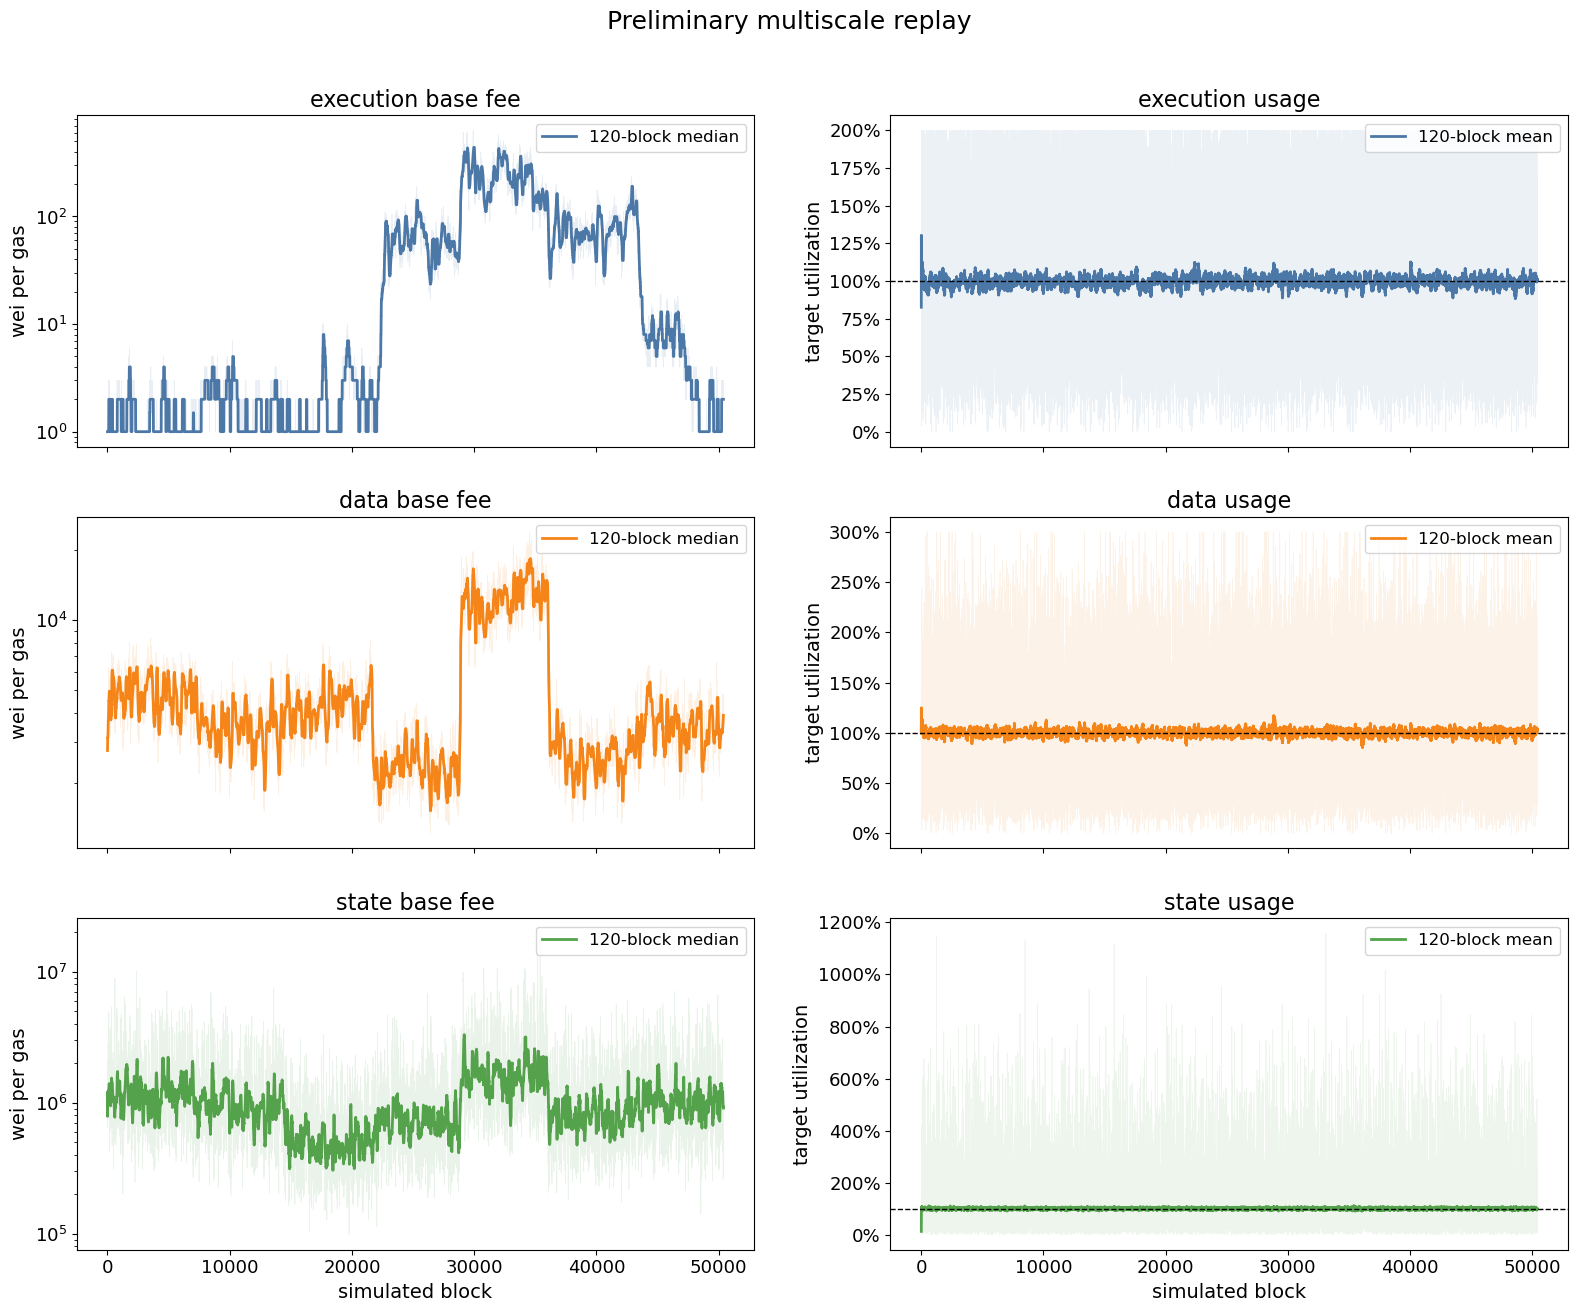

In [10]:
fig, axes = plt.subplots(3, 2, figsize=(16, 13), sharex=True)
block_axis = baseline_replay.index.to_numpy()
ROLLING_BLOCKS = 120
for row_number, resource in enumerate(RESOURCES):
    axes[row_number, 0].plot(
        block_axis,
        baseline_replay[f"{resource}_base_fee_wei"],
        color=COLORS[resource],
        linewidth=0.5,
        alpha=0.12,
    )
    axes[row_number, 0].plot(
        block_axis,
        baseline_replay[f"{resource}_base_fee_wei"].rolling(
            ROLLING_BLOCKS,
            min_periods=1,
        ).median(),
        color=COLORS[resource],
        linewidth=2,
        label=f"{ROLLING_BLOCKS}-block median",
    )
    axes[row_number, 0].set_yscale("log")
    axes[row_number, 0].set_ylabel("wei per gas")
    axes[row_number, 0].set_title(f"{RESOURCE_LABELS[resource]} base fee")

    axes[row_number, 1].plot(
        block_axis,
        100 * baseline_replay[f"{resource}_pct_target"],
        color=COLORS[resource],
        linewidth=0.5,
        alpha=0.10,
    )
    axes[row_number, 1].plot(
        block_axis,
        100 * baseline_replay[f"{resource}_pct_target"].rolling(
            ROLLING_BLOCKS,
            min_periods=1,
        ).mean(),
        color=COLORS[resource],
        linewidth=2,
        label=f"{ROLLING_BLOCKS}-block mean",
    )
    axes[row_number, 1].axhline(
        100, color="black", linewidth=1, linestyle="--"
    )
    axes[row_number, 1].set_ylabel("target utilization")
    axes[row_number, 1].yaxis.set_major_formatter(
        plt.FuncFormatter(lambda value, _: f"{value:.0f}%")
    )
    axes[row_number, 1].set_title(f"{RESOURCE_LABELS[resource]} usage")
    axes[row_number, 0].legend(loc="upper right")
    axes[row_number, 1].legend(loc="upper right")

for axis in axes[-1, :]:
    axis.set_xlabel("simulated block")
fig.suptitle("Preliminary multiscale replay", y=1.01)
fig.tight_layout(h_pad=2.0, w_pad=2.0)
fig.savefig(
    PLOTS_DIR / f"bundle_dynamic_baseline_replay_{DATE_LABEL}.png",
    dpi=180,
    bbox_inches="tight",
)
plt.show()


## Directional stress experiments

Each stress uses the same empirical path and adds a twofold demand pulse that
decays with a 120-block half-life. This is a designed mechanism experiment,
not a claim about the frequency or cause of historical events.

- execution stress raises execution activity and execution-linked BAL;
- static-data stress raises only static transaction data on impact;
- state stress raises state creation and state-linked BAL;
- joint stress raises all three parent demand conditions.

The fee used in the shocked block is inherited from its parent. Usage changes
first; the next block's fee then reacts.


In [11]:
STRESS_ONSET = 3 * BLOCKS_PER_DAY
STRESS_HALF_LIFE = 120
STRESS_DURATION = 900
STRESS_PEAK = 2.0

def add_stress(path, stressed_resources):
    values = path.values.copy()
    offsets = np.arange(STRESS_DURATION)
    pulse = 1.0 + (STRESS_PEAK - 1.0) * 0.5 ** (
        offsets / STRESS_HALF_LIFE
    )
    stop = min(STRESS_ONSET + STRESS_DURATION, len(values))
    pulse = pulse[: stop - STRESS_ONSET]
    for resource in stressed_resources:
        values.loc[STRESS_ONSET : stop - 1, resource] *= pulse
    return JointShockPath(
        values=values,
        frequency="block",
        basis=path.basis,
        source=(
            f"{path.source}; 2x decaying stress in "
            + ",".join(stressed_resources)
        ),
        source_positions=path.source_positions,
    )

stress_specs = {
    "baseline": (),
    "execution": ("execution",),
    "static data": ("data",),
    "state": ("state",),
    "joint": RESOURCES,
}
stress_replays = {"baseline": baseline_replay}
for name, stressed_resources in stress_specs.items():
    if name == "baseline":
        continue
    stress_replays[name] = run_driven_full_7999(
        config=replay_config(reserve_factor=0),
        demand_model=demand_model,
        shock_path=add_stress(empirical_path, stressed_resources),
        blob_base_fee_per_gas=None,
        inclusion_rule=ParentBALConsistentCaps(),
        access_shock_path=empirical_access,
    )

stress_summary_rows = []
window = slice(STRESS_ONSET, STRESS_ONSET + STRESS_DURATION - 1)
for scenario, replay in stress_replays.items():
    for resource in RESOURCES:
        fee = replay.loc[window, f"{resource}_base_fee_wei"]
        usage = replay.loc[window, f"{resource}_included_gas"]
        baseline_fee = baseline_replay.loc[
            window, f"{resource}_base_fee_wei"
        ]
        stress_summary_rows.append(
            {
                "scenario": scenario,
                "resource": resource,
                "maximum fee (wei)": int(fee.max()),
                "maximum fee relative to baseline": float(
                    (fee / baseline_fee.clip(lower=1)).max()
                ),
                "maximum target utilization": float(
                    (
                        usage
                        / replay.loc[window, f"{resource}_gas_target"]
                    ).max()
                ),
                "limit-hit blocks": int(
                    replay.loc[window, f"{resource}_limit_hit"].sum()
                ),
            }
        )
stress_summary = pd.DataFrame(stress_summary_rows)
stress_summary.to_csv(
    DATA_DIR / f"bundle_dynamic_stress_summary_{DATE_LABEL}.csv",
    index=False,
)
display(stress_summary)


,scenario,resource,maximum fee (wei),maximum fee relative to baseline,maximum target utilization,limit-hit blocks
0,baseline,execution,32,1,2,38
1,baseline,data,4915,1,3,1
2,baseline,state,3480832,1,7.95948,0
3,execution,execution,1175,885,2,41
4,execution,data,5971,1.78848,2.7977,0
5,execution,state,3480837,1.00313,7.95948,0
6,static data,execution,11,1,2,25
7,static data,data,14202,4.73644,3,1
8,static data,state,3480816,1.00306,7.95947,0
9,state,execution,32,1,2,38


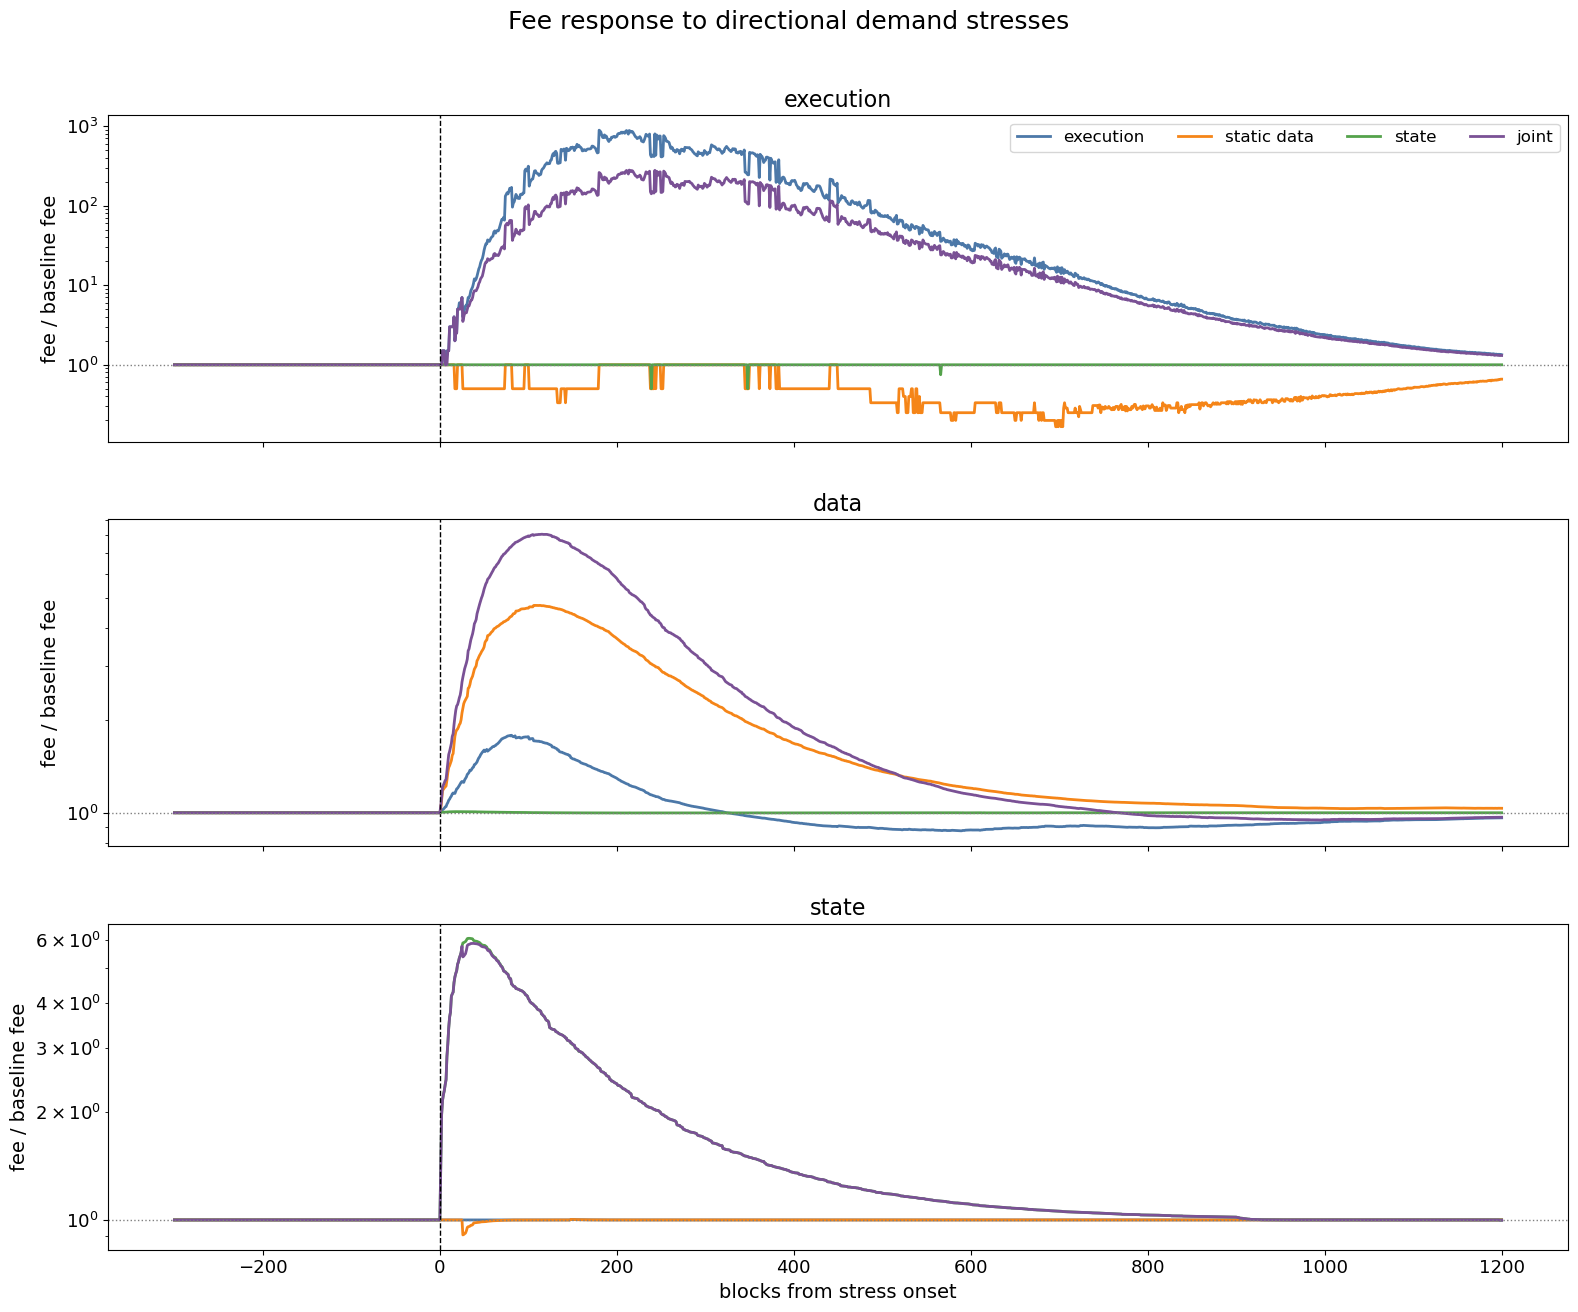

In [12]:
plot_start = STRESS_ONSET - 300
plot_stop = STRESS_ONSET + 1_200
fig, axes = plt.subplots(3, 1, figsize=(16, 13), sharex=True)
scenario_colors = {
    "execution": "#4c78a8",
    "static data": "#f58518",
    "state": "#54a24b",
    "joint": "#7a5195",
}
for axis, resource in zip(axes, RESOURCES):
    baseline_fee = baseline_replay.loc[
        plot_start:plot_stop, f"{resource}_base_fee_wei"
    ].clip(lower=1)
    for scenario, replay in stress_replays.items():
        if scenario == "baseline":
            continue
        ratio = (
            replay.loc[plot_start:plot_stop, f"{resource}_base_fee_wei"]
            / baseline_fee
        )
        axis.plot(
            np.arange(plot_start, plot_stop + 1) - STRESS_ONSET,
            ratio,
            linewidth=2,
            color=scenario_colors[scenario],
            label=scenario,
        )
    axis.axvline(0, color="black", linewidth=1, linestyle="--")
    axis.axhline(1, color="grey", linewidth=1, linestyle=":")
    axis.set_yscale("log")
    axis.set_ylabel("fee / baseline fee")
    axis.set_title(RESOURCE_LABELS[resource])
axes[0].legend(ncol=4)
axes[-1].set_xlabel("blocks from stress onset")
fig.suptitle("Fee response to directional demand stresses", y=1.01)
fig.tight_layout(h_pad=2.4)
fig.savefig(
    PLOTS_DIR / f"bundle_dynamic_stress_response_{DATE_LABEL}.png",
    dpi=180,
    bbox_inches="tight",
)
plt.show()


## Data-reserve scenario

The reserve depends on the counterfactual blob base-fee path, which is not
identified by the demand model. This first sensitivity holds the blob base fee
at the median of the cached 500-block sample. It shows the mechanism implied by
that assumption; it is not a forecast of the future blob fee.


In [13]:
blob_history = pd.read_csv(
    DATA_DIR / "blob_base_fee_calldata_24120001_24120500.csv"
)
fixed_blob_fee = int(round(blob_history["blob_base_fee_per_gas"].median()))
reserve_replay = run_driven_full_7999(
    config=replay_config(reserve_factor=12),
    demand_model=demand_model,
    shock_path=empirical_path,
    blob_base_fee_per_gas=fixed_blob_fee,
    inclusion_rule=ParentBALConsistentCaps(),
    access_shock_path=empirical_access,
)
reserve_summary = summarize_driven_replay(
    reserve_replay,
    burn_in_blocks=BLOCKS_PER_DAY,
)
display(
    pd.concat(
        [
            baseline_summary.assign(reserve="off"),
            reserve_summary.assign(reserve="historical-median blob fee"),
        ],
        ignore_index=True,
    )
)
print(f"Fixed blob base fee: {fixed_blob_fee:,} wei per blob gas")
print(
    "Initial reserve threshold: "
    f"{int(np.ceil(fixed_blob_fee / 12)):,.0f} wei per data gas"
)


,resource,blocks,mean_base_fee_wei,median_base_fee_wei,p90_base_fee_wei,p99_base_fee_wei,maximum_base_fee_wei,base_fee_floor_fraction,base_fee_log_return_std,mean_included_gas,p99_included_gas,mean_target_fill,target_or_above_fraction,own_limit_exceeded_fraction,rationed_fraction,limit_hit_fraction,mean_unserved_gas,maximum_unserved_gas,reserve_active_fraction,maximum_reserve_run_blocks,reserve
0,execution,43200,64.6209,13,199,411,631,0.193889,0.101234,1.81864e+08,3.645e+08,0.997883,0.443333,0.0278009,0.0291898,0.0276389,"839,874",1.40607e+08,NaN,NaN,off
1,data,43200,"4,873.17","3,437","11,899","17,466.2","23,937",0,0.0374047,2.99981e+07,7.13581e+07,0.999936,0.439815,0.00162037,0.0291898,0.00155093,"46,139.9",2.33319e+07,0,0,off
2,state,43200,1.10697e+06,"868,960",2.07094e+06,4.4092e+06,1.95899e+07,0,0.216315,7.50031e+07,3.67241e+08,1.00004,0.340185,NaN,0.00155093,NaN,"22,569.8",6.62045e+07,NaN,NaN,off
3,execution,43200,1,1,1,1,1,1,0,1.08448e+08,2.40314e+08,0.595053,0.0862963,0,0,0,0,0,NaN,NaN,historical-median blob fee
4,data,43200,"369,438","369,579","380,471","388,448","403,748",0,0.0340746,1.30471e+07,3.11524e+07,0.434904,0.0126389,0,0,0,0,0,0.660324,6,historical-median blob fee
5,state,43200,1.10474e+06,"866,680",2.06955e+06,4.408e+06,1.95739e+07,0,0.216359,7.50031e+07,3.67353e+08,1.00004,0.340069,NaN,0,NaN,0,0,NaN,NaN,historical-median blob fee


Fixed blob base fee: 4,484,147 wei per blob gas
Initial reserve threshold: 373,679 wei per data gas


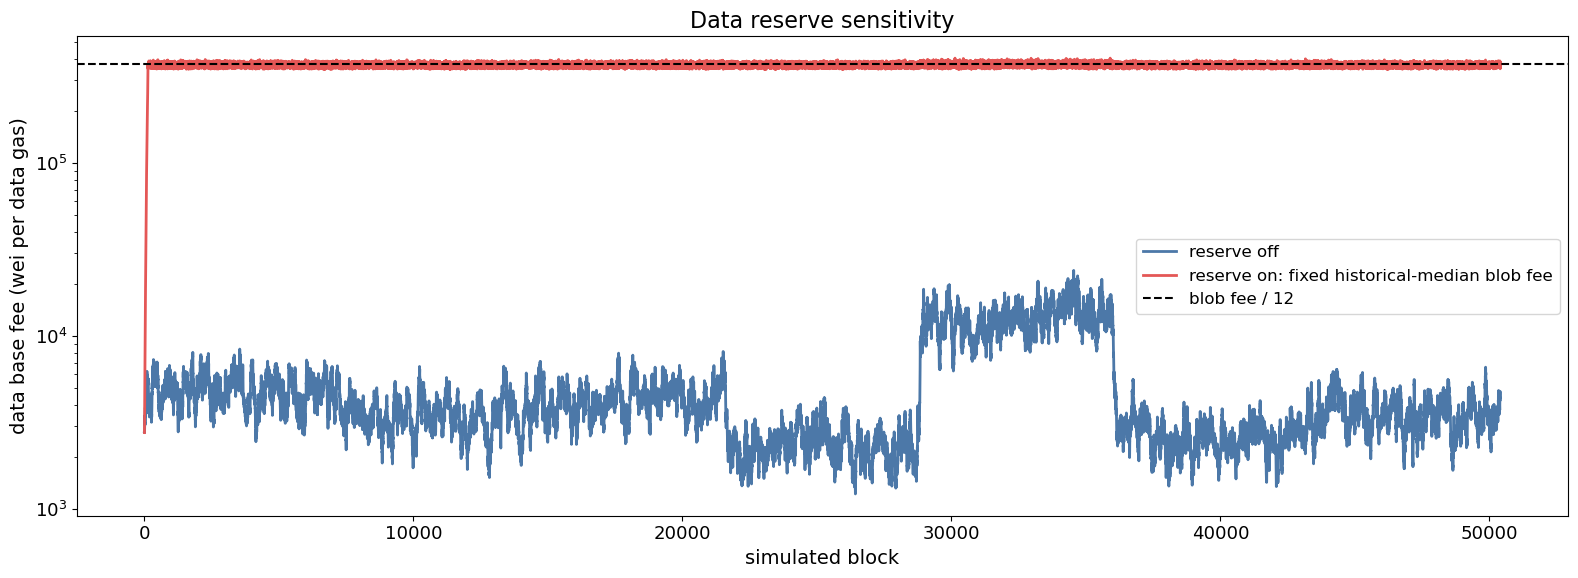

In [14]:
fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(
    baseline_replay.index,
    baseline_replay["data_base_fee_wei"],
    linewidth=2,
    label="reserve off",
    color="#4c78a8",
)
ax.plot(
    reserve_replay.index,
    reserve_replay["data_base_fee_wei"],
    linewidth=2,
    label="reserve on: fixed historical-median blob fee",
    color="#e45756",
)
ax.axhline(
    fixed_blob_fee / 12,
    linewidth=1.5,
    linestyle="--",
    color="black",
    label="blob fee / 12",
)
ax.set_yscale("log")
ax.set_xlabel("simulated block")
ax.set_ylabel("data base fee (wei per data gas)")
ax.set_title("Data reserve sensitivity")
ax.legend()
fig.tight_layout()
fig.savefig(
    PLOTS_DIR / f"bundle_dynamic_reserve_sensitivity_{DATE_LABEL}.png",
    dpi=180,
    bbox_inches="tight",
)
plt.show()


## Interpretation and next empirical step

This notebook establishes the correct dynamic accounting:

1. current fees and the current demand-condition vector determine offered
   execution, static data, state creation, and induced BAL;
2. current-block usage updates the three excess-gas states;
3. the resulting fees govern the next block;
4. a higher data fee feeds back into execution and state through their BAL
   charges.

The historical decomposition should be read carefully. Price and external
demand cannot be separated without a maintained demand model. Here the event-
estimated elasticity removes the modeled price response, and the unexplained
joint residual is treated as the demand environment. Re-estimating the residual
under every elasticity window exposes that dependence.

The displayed block-frequency results remain mechanics diagnostics because
the interim within-day factors are neither contiguous nor price-adjusted. A
common access-composition residual scales both BAL components; separate
execution- and state-linked residuals remain a later sensitivity.
The next measurement task is a long contiguous Xatu-only block panel. It needs
historical base fee, regular execution, static data, and the EIP-8037 state
proxy and a runtime-BAL measure for access-composition variation. The existing
runtime reconstruction can supply the latter without a new exact-RLP exercise.
That panel will replace the interim within-day factors and
identify block-level persistence, upper-tail run lengths, and fee volatility.

Two limitations remain for later extensions:

- historical full blocks censor offered execution demand, so empirical upper
  tails are likely understated;
- when a hard limit binds, aggregate clipping does not identify which
  transactions—and therefore which linked BAL—are included. The current runs
  report those blocks rather than hiding this allocation assumption.
